In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\Salary_Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [3]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [4]:
# Fill all numeric columns' NaN values with their respective column median
df = df.fillna(df.median(numeric_only=True))


In [5]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


In [6]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [7]:
df.duplicated().sum() 

np.int64(4912)

In [8]:
# Remove duplicates and keep only the first occurrence
df = df.drop_duplicates()


In [9]:
df.duplicated().sum() 

np.int64(0)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


In [11]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,177,5.0,90000.0
1,28.0,0,3,18,3.0,65000.0
2,45.0,1,5,145,15.0,150000.0
3,36.0,0,0,116,7.0,60000.0
4,52.0,1,3,26,20.0,200000.0


In [12]:
import pandas as pd

# Example: suppose df is your dataset and 'target' is your output column
corr_with_target = df.corr(method='pearson')['Salary'].sort_values(ascending=False)

print("Correlation of each feature with target:")
print(corr_with_target)


Correlation of each feature with target:
Salary                 1.000000
Years of Experience    0.818606
Age                    0.766367
Education Level        0.499890
Job Title              0.152205
Gender                 0.104573
Name: Salary, dtype: float64


In [13]:
# Independent and dependent variables
X = df[['Years of Experience', 'Age']]
y = df[['Salary']]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler
# Create two separate scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()
# Scale X
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale y (important: reshape to 2D before scaling)
y_train_scaled = scaler_y.fit_transform(y_train)
# Note: y_test is not needed for fitting, only transform
y_test_scaled = scaler_y.transform(y_test)

In [17]:
X_train_scaled
X_test_scaled

array([[-0.60476976, -0.73844285],
       [-0.89345566, -0.49604482],
       [-0.02739796, -0.25364679],
       [-0.60476976, -0.98084089],
       [-0.60476976, -0.73844285],
       [-1.0377986 , -0.73844285],
       [ 1.70471742,  0.95834337],
       [ 0.11694498,  0.35234829],
       [-0.74911271, -0.85964187],
       [-0.17174091, -0.49604482],
       [-0.74911271, -0.98084089],
       [-1.0377986 , -0.98084089],
       [-0.89345566, -0.37484581],
       [-1.0377986 , -0.98084089],
       [-1.0377986 , -0.01124876],
       [-0.02739796, -0.13244777],
       [-0.89345566, -0.85964187],
       [ 0.98300268,  0.95834337],
       [ 1.41603152,  1.2007414 ],
       [ 0.11694498, -0.13244777],
       [ 1.84906037,  1.68553747],
       [-0.46042681, -0.25364679],
       [-0.31608386,  0.10995026],
       [-0.46042681, -0.37484581],
       [-1.0377986 , -0.49604482],
       [-0.17174091, -0.01124876],
       [-1.18214155, -1.22323892],
       [-0.89345566, -0.61724384],
       [-0.74911271,

In [32]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train_scaled)


KNeighborsRegressor()

In [33]:
y_pred = knn.predict(X_test_scaled)

mse = mean_squared_error(y_test_scaled, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")


Mean Squared Error: 0.226
R² Score: -5.286


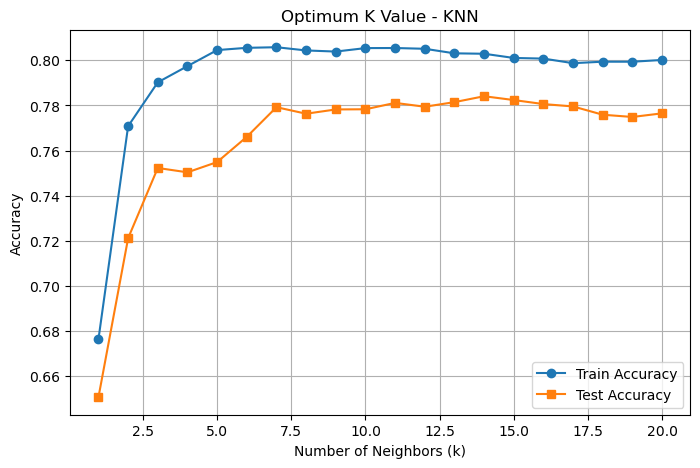

✅ Optimum K Value: 14
Test Accuracy at K=14: 0.784


In [34]:
# Check accuracy for different k values
k_values = range(1, 21)
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_scaled)
    train_acc.append(knn.score(X_train_scaled, y_train_scaled))
    test_acc.append(knn.score(X_test_scaled, y_test_scaled))

# Plot accuracy vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(k_values, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Optimum K Value - KNN')
plt.legend()
plt.grid(True)
plt.show()

# Find best K
best_k = k_values[test_acc.index(max(test_acc))]
print(f"✅ Optimum K Value: {best_k}")
print(f"Test Accuracy at K={best_k}: {max(test_acc):.3f}")

In [21]:
# we get the optimum k value as 14 so now we can train the model with new k value

In [63]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
# Scale both X and y
X_scaler = StandardScaler()
y_scaler = StandardScaler()


In [65]:
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()


In [71]:
knn = KNeighborsRegressor(n_neighbors=14)
loo = LeaveOneOut()

y_true_scaled = []
y_pred_scaled = []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_scaled[train_index], y_scaled[test_index]

    knn.fit(X_train, y_train)
    y_pred_scaled.append(knn.predict(X_test)[0])
    y_true_scaled.append(y_test[0])


In [76]:
# Compute metrics in scaled space
mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print(f"Scaled LOOCV MSE: {mse_scaled:.4f}")
print(f"Scaled LOOCV R²: {r2_scaled:.4f}")

Scaled LOOCV MSE: 0.2328
Scaled LOOCV R²: 0.7672


In [75]:
#here we got an average model